This script aligns NOAA's 1-12 month climate forecasts with observed crop yield for a given growing season and crop type
Shrad 08/17/2026

In [2]:
# This script processes NOAA climate forecasts and calculates their correlaiton with the crop yield data

In [3]:
import geopandas as gpd
import salem
import pandas as pd
import numpy as np
import xarray as xr
from scipy.stats import spearmanr
import os
import glob
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

# Plotting
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
plt.style.use('ggplot')

In [18]:
## Define data directories and file paths
datadir = '/home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/data/outputs/noaa_cf_vs_yield'
os.makedirs(datadir, exist_ok=True)

plotdir = '/home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/results/noaa_cf_vs_yield'
os.makedirs(plotdir, exist_ok=True)

In [5]:
crop_data_dir = '/home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/data/inputs/hvstat'
crop_data_file = f"{crop_data_dir}/hvstat_africa_data_v1.2.csv"
admin_shapefile = f"{crop_data_dir}/hvstat_africa_boundary_v1.2.gpkg"
crop_data = pd.read_csv(crop_data_file)
admin_shp = gpd.read_file(admin_shapefile)
## Reading SIF data and shape file
syr, eyr = 1991, 2023
date_range = pd.date_range(start=f'{syr}-01-01', end=f'{eyr}-12-31', freq='ME')
noaa_cf_data = xr.open_dataset('/home/chc-shrad/DATA/Crop_yield_forecasting/noaa_experimental_climate_forecasts/CHIRPS3_Prate_Monthly_Forecasts_1981_2023_leads1-12_1x1deg.nc')
noaa_cf_data = noaa_cf_data.rename({'latitude':'lat', 'longitude':'lon'})
#chirps_data = chirps_data.rename({'Y':'lat', 'X':'lon'})
crop_fraction_threshold = 0.1

In [6]:
chirps_data = xr.open_dataset('/home/chc-shrad/DATA/Crop_yield_forecasting/noaa_experimental_climate_forecasts/chirpsv3_regridded_to_NMME_1981-2024_conservative_normed_converted_to_mm_per_day.nc')
chirps_data_xr = xr.DataArray(
    data=chirps_data['prec'].values,
    dims=["time", "lat", "lon"],
    coords=dict(
        lon=(chirps_data.longitude.values),
        lat=(chirps_data.latitude.values),
        time=chirps_data.coords['time'].values,
    ))

chirps_data_xr.coords['lon'] = (chirps_data_xr.coords['lon'] + 180) % 360 -180
chirps_data_xr = chirps_data_xr.sortby(chirps_data_xr.lon)
sel_chirps_data_xr = chirps_data_xr.sel(lat=slice(-60, 60))

In [7]:
from dateutil.relativedelta import relativedelta
def relativedelta_months(start, end):
    return relativedelta(end, start).months + relativedelta(end, start).years * 12

In [8]:
for crop_mask_type in ['lu']:
    crop_mask_file = f'/home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/data/inputs/{crop_mask_type}_crop_mask_fraction_on_noaa_fcst_grid_conservative.nc'
    crop_mask = xr.open_dataset(crop_mask_file)
    for crop_type in ['Maize']:
        # Subsetting crop data for a given crop type, quality control flag, and harvest year range
        sel_crop_data = crop_data[(crop_data['product'] == crop_type) & (crop_data['country'] == 'South Africa') & (crop_data['qc_flag']==0) & (crop_data['harvest_year']>=syr) & (crop_data['harvest_year']<=eyr)]
        sel_crop_data = sel_crop_data.dropna()
        # Getting unique subsets of crop data based on relevant columns
        unique_subsets = sel_crop_data[['country', 'fnid', 'product', 'crop_production_system', 'season_name', 'planting_year', 'planting_month', 'harvest_year', 'harvest_month', 'yield']].drop_duplicates()
        fnid = None
        # Loop over unique subsets in crop data to calculate seasonal SIF metrics and store results
        results = []
        for index, subset in unique_subsets.iterrows():
            #print (f"Processing subset: {subset.to_dict()}")

            fnid_new = subset['fnid']
            if fnid_new != fnid:
                fnid = fnid_new
                # Only subset the SIF and crop mask data if the fnid has changed
                print(f"Processing new fnid: {fnid}")
                fnid_admin_shp = admin_shp[admin_shp['fnid'] == fnid]
                if not fnid_admin_shp.empty:
                    noaa_cf_subset = noaa_cf_data.salem.subset(shape=fnid_admin_shp, margin=2)
                    crop_mask_subset = crop_mask.salem.subset(shape=fnid_admin_shp, margin=2)
                    chirps_mask_subset = sel_chirps_data_xr.salem.subset(shape=fnid_admin_shp, margin=2)
                    flag = True
                else:
                    flag = False
            else:
                pass

            if flag:
                p_year = int(subset['planting_year'])
                p_month = int(subset['planting_month'])
                h_year = int(subset['harvest_year'])
                h_month = int(subset['harvest_month'])

                
                # Season window: from first day of planting month to end of harvest month
                season_start = pd.Timestamp(p_year, p_month, 1)
                season_end = pd.Timestamp(h_year, h_month, 1) + pd.offsets.MonthEnd(1)

                seasonal_chirps = chirps_mask_subset.sel(time=slice(season_start, season_end)).sum(dim='time')
                seasonal_chirps_masked = seasonal_chirps.where(crop_mask_subset['crop_fraction']>=crop_fraction_threshold)
                chirps_agg = seasonal_chirps.sum()
                chirps_masked_agg = seasonal_chirps_masked.sum()

                for lead in range(12, 1, -1):
                    ic_date = season_end-pd.DateOffset(months=lead-1)
                    ic_date = pd.Timestamp(ic_date.year, ic_date.month, 1)

                    ## Calculating growing season start and end leads in months since the initial condition date
                    gs_start_lead = relativedelta_months(ic_date, season_start)+1
                    gs_end_lead = relativedelta_months(ic_date, season_end)+1
                    if (gs_start_lead>=1):
                        #print(f"GS {season_start}, {season_end}, Lead {lead}: {ic_date}, GS Start Lead: {gs_start_lead}, GS End Lead: {gs_end_lead}")
                        gs_fcst = noaa_cf_subset.sel(time=ic_date).sel(leads=slice(gs_start_lead, gs_end_lead)).sum(dim='leads')
                        gs_fcst_masked = gs_fcst.where(crop_mask_subset['crop_fraction']>=crop_fraction_threshold)
                        gs_fcst_agg = gs_fcst['precip_forecast'].sum()
                        gs_fcst_masked_agg = gs_fcst_masked['precip_forecast'].sum()
                        # Append to results
                        results.append({
                            'country': subset['country'],
                            'fnid': subset['fnid'],
                            'product':subset['product'],
                            'crop_production_system':subset['crop_production_system'],
                            'season_name':subset['season_name'],
                            'planting_month': subset['planting_month'],
                            'planting_year': subset['planting_year'],
                            'harvest_month': subset['harvest_month'],
                            'harvest_year': subset['harvest_year'],
                            'yield': subset['yield'],
                            'noaa_cf_mm': np.round(gs_fcst_agg.values, 3),
                            'noaa_cf_masked_mm': np.round(gs_fcst_masked_agg.values, 3),
                            'chirps_mm': np.round(chirps_agg.values, 3),
                            'chirps_masked_mm': np.round(chirps_masked_agg.values, 3),
                            'ic_date': ic_date,
                            'gs_start_lead': gs_start_lead,
                            'gs_end_lead': gs_end_lead,
                            'crop_mask_type': crop_mask_type
                        })
                        
                    else:
                        pass
            else:
                print(f"No shape file found for fnid: {fnid}. Skipping this subset.")
                continue
            
        results_df = pd.DataFrame(results)
        # Save results to CSV
        output_file = f"{datadir}/noaa_cfs_vs_yield_{syr}_{eyr}_{crop_type}_crop_{crop_mask_type}_crop_mask.csv"
        print (f"Saving results to {output_file}")
        results_df.to_csv(output_file, index=False)

                


Processing new fnid: ZA1994A101
Processing new fnid: ZA1994A102
Processing new fnid: ZA1994A103
Processing new fnid: ZA1994A104
Processing new fnid: ZA1994A105
Processing new fnid: ZA1994A106
Processing new fnid: ZA1994A107
Processing new fnid: ZA1994A108
Processing new fnid: ZA1994A109
Saving results to /home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/data/outputs/noaa_cf_vs_yield/noaa_cfs_vs_yield_1991_2023_Maize_crop_lu_crop_mask.csv


In [13]:
results_cf = []
results_obs = []
for fnid in results_df['fnid'].unique():
    sel_fnid_data = results_df[results_df['fnid']==fnid]
    for lead in sel_fnid_data['gs_end_lead'].unique():
        sel_cf_yield = sel_fnid_data[sel_fnid_data['gs_end_lead']==lead][['harvest_year', 'noaa_cf_mm', 'noaa_cf_masked_mm', 'yield', 'chirps_mm', 'chirps_masked_mm']]

        ## Calculating Spearman correlation between NOAA climate forecast and crop yield
        noaa_cf_corr_all = spearmanr(sel_cf_yield['yield'], sel_cf_yield['noaa_cf_mm'])[0]
        noaa_cf_corr_masked = spearmanr(sel_cf_yield['yield'], sel_cf_yield['noaa_cf_masked_mm'])[0]
        noaa_cf_corr_all_diff = spearmanr(sel_cf_yield['yield'].diff().dropna(), sel_cf_yield['noaa_cf_mm'].diff().dropna())[0]
        noaa_cf_corr_masked_diff = spearmanr(sel_cf_yield['yield'].diff().dropna(), sel_cf_yield['noaa_cf_masked_mm'].diff().dropna())[0]
        
        results_cf.append({
        'fnid': fnid,
        'lead': lead,
        'noaa_corr_all': noaa_cf_corr_all,
        'noaa_corr_masked': noaa_cf_corr_masked,
        'noaa_corr_all_diff': noaa_cf_corr_all_diff,
        'noaa_corr_masked_diff': noaa_cf_corr_masked_diff})

    ## Calculating Spearman correlation between chirps obs and crop yield
    chirps_corr_all = spearmanr(sel_cf_yield['yield'], sel_cf_yield['chirps_mm'])[0]
    chirps_corr_all_diff = spearmanr(sel_cf_yield['yield'].diff().dropna(), sel_cf_yield['chirps_mm'].diff().dropna())[0]
    chirps_corr_mask = spearmanr(sel_cf_yield['yield'], sel_cf_yield['chirps_masked_mm'])[0]
    chirps_corr_mask_diff = spearmanr(sel_cf_yield['yield'].diff().dropna(), sel_cf_yield['chirps_masked_mm'].diff().dropna())[0]
    
    results_obs.append({
    'fnid': fnid,
    'lead': 0,
    'chirps_corr_all': chirps_corr_all,
    'chirps_corr_all_diff': chirps_corr_all_diff,
    'chirps_corr_masked': chirps_corr_mask,
    'chirps_corr_masked_diff': chirps_corr_mask_diff})
noaa_cf_corr_df = pd.DataFrame(results_cf)
chirps_corr_df = pd.DataFrame(results_obs)


Saving correlation maps to /home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/results/noaa_cf_vs_yield/noaa_cfs_vs_yield_1991_2023_Maize_crop_lu_crop_mask_correlation_maps.png


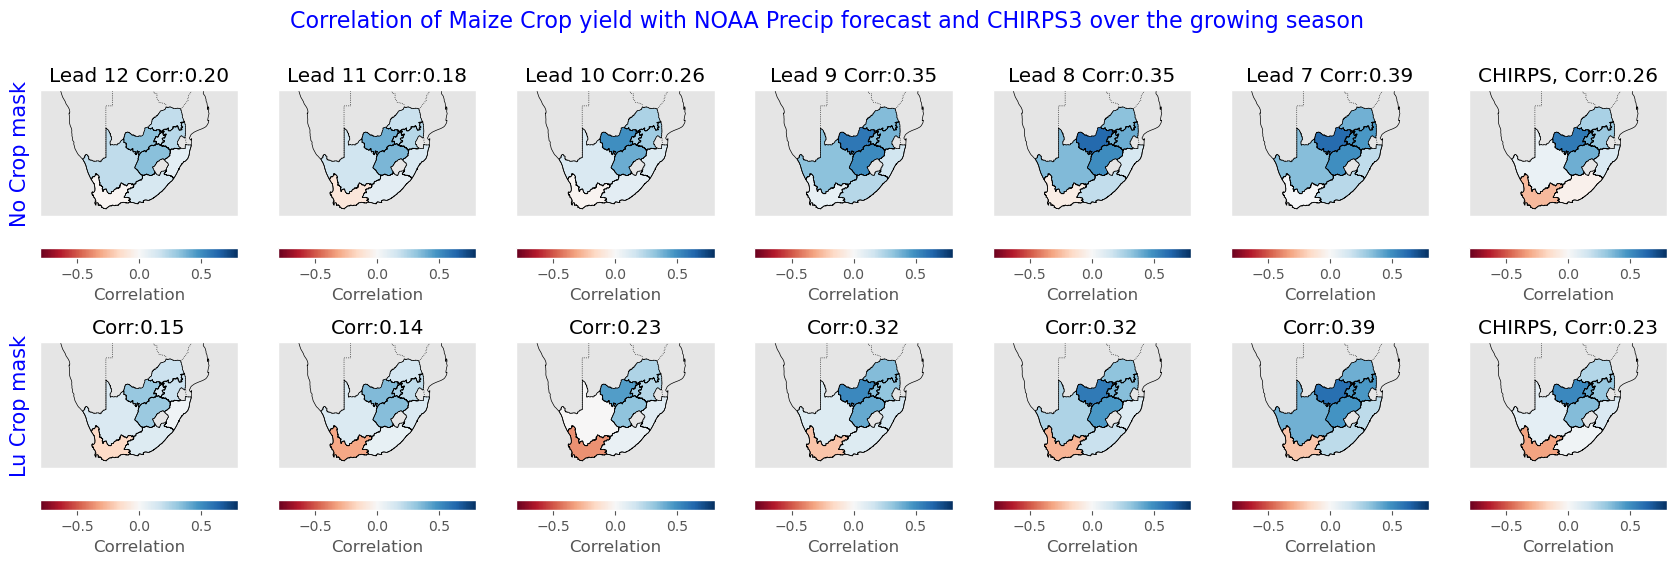

In [19]:
noaa_merged_df = pd.merge(noaa_cf_corr_df, admin_shp, on='fnid')
noaa_merged_gdf = gpd.GeoDataFrame(noaa_merged_df, geometry='geometry')

chirps_merged_df = pd.merge(chirps_corr_df, admin_shp, on='fnid')
chirps_merged_gdf = gpd.GeoDataFrame(chirps_merged_df, geometry='geometry')


nrows, ncols = 2, 7
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*3, nrows*3), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()
for plt_cnt, lead in enumerate(range(12, 6, -1)):
    ax = axes[plt_cnt]
    noaa_merged_gdf[noaa_merged_gdf['lead']==lead].plot(ax=ax, column='noaa_corr_all', vmin=-0.8, vmax=0.8, cmap='RdBu', legend=True, 
                                              legend_kwds={'orientation':'horizontal', 'label': 'Correlation'})
    if plt_cnt == 0:
        ax.text(-0.1, 0.5, 'No Crop mask', fontsize=15, color='blue', transform=ax.transAxes, ha='center', va='center', rotation=90)
    noaa_merged_gdf[noaa_merged_gdf['lead']==lead].boundary.plot(ax=ax, edgecolor='black', lw=0.5)
    median_corr = noaa_merged_gdf[noaa_merged_gdf['lead']==lead]['noaa_corr_all'].median()
    ax.set_title(f'Lead {lead} Corr:{median_corr:0.2f}')
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_extent([10, 40, -35, -20])

ax=axes[6]
chirps_merged_gdf.plot(ax=ax, column='chirps_corr_all', vmin=-0.8, vmax=0.8, cmap='RdBu', legend=True, 
                                              legend_kwds={'orientation':'horizontal', 'label': 'Correlation'})
chirps_merged_gdf.boundary.plot(ax=ax, edgecolor='black', lw=0.5)
median_corr = chirps_merged_gdf['chirps_corr_all'].median()
ax.set_title(f'CHIRPS, Corr:{median_corr:0.2f}')
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_extent([10, 40, -35, -20])

for plt_cnt, lead in enumerate(range(12, 6, -1)):
    ax = axes[plt_cnt+7]
    noaa_merged_gdf[noaa_merged_gdf['lead']==lead].plot(ax=ax, column='noaa_corr_masked', vmin=-0.8, vmax=0.8, cmap='RdBu', legend=True, 
                                              legend_kwds={'orientation':'horizontal', 'label': 'Correlation'})
    #ax.set_title(f'Lead {lead}')
    if plt_cnt == 0:
        ax.text(-0.1, 0.5, 'Lu Crop mask', fontsize=15, color='blue', transform=ax.transAxes, ha='center', va='center', rotation=90)
    noaa_merged_gdf[noaa_merged_gdf['lead']==lead].boundary.plot(ax=ax, edgecolor='black', lw=0.5)
    median_corr = noaa_merged_gdf[noaa_merged_gdf['lead']==lead]['noaa_corr_masked'].median()
    ax.set_title(f'Corr:{median_corr:0.2f}')
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_extent([10, 40, -35, -20])


ax=axes[13]
chirps_merged_gdf.plot(ax=ax, column='chirps_corr_masked', vmin=-0.8, vmax=0.8, cmap='RdBu', legend=True, 
                                              legend_kwds={'orientation':'horizontal', 'label': 'Correlation'})
chirps_merged_gdf.boundary.plot(ax=ax, edgecolor='black', lw=0.5)
median_corr = chirps_merged_gdf['chirps_corr_masked'].median()
ax.set_title(f'CHIRPS, Corr:{median_corr:0.2f}')
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_extent([10, 40, -35, -20])

fig.suptitle('Correlation of Maize Crop yield with NOAA Precip forecast and CHIRPS3 over the growing season', fontsize=16, color='blue')

output_file = f"{plotdir}/noaa_cfs_vs_yield_{syr}_{eyr}_{crop_type}_crop_{crop_mask_type}_crop_mask_correlation_maps.png"
print (f"Saving correlation maps to {output_file}")
plt.savefig(output_file, dpi=300, bbox_inches='tight')
#

Saving correlation maps to /home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/results/noaa_cf_vs_yield/noaa_cfs_vs_yield_1991_2023_Maize_crop_lu_crop_mask_first_diff_correlation_maps.png


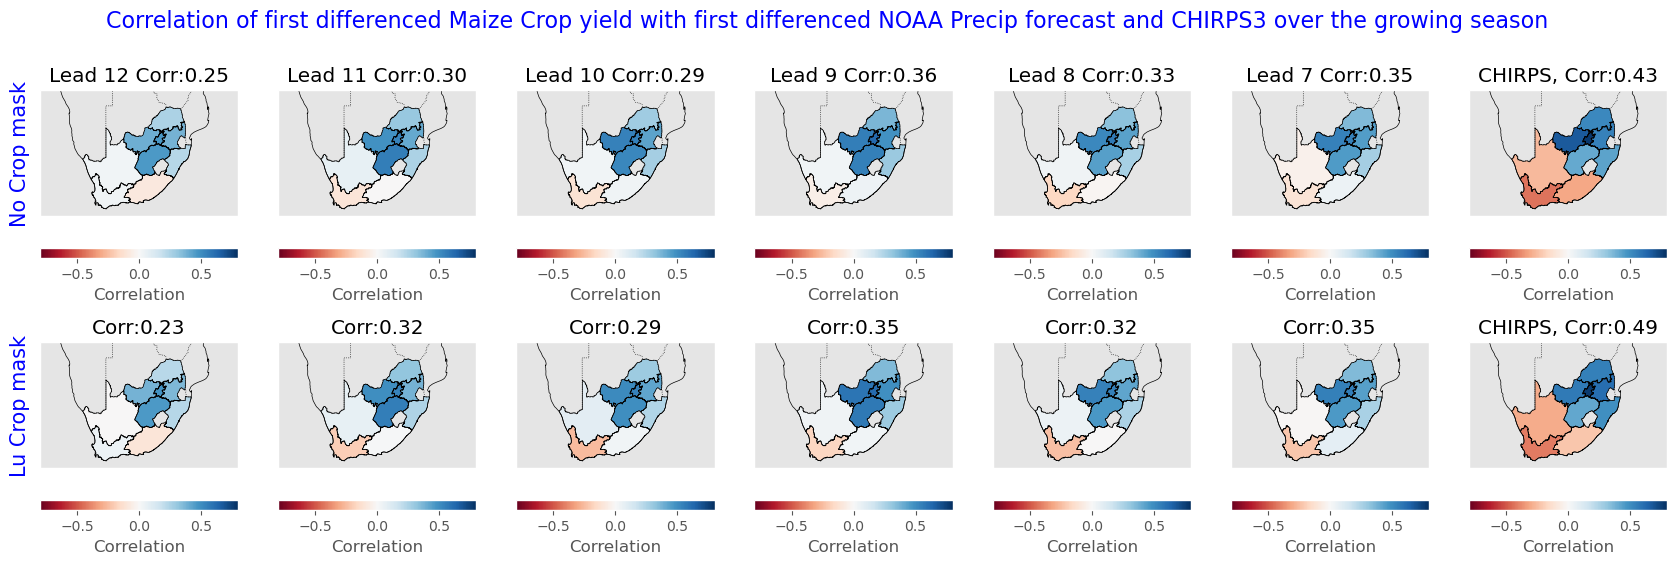

In [20]:
noaa_merged_df = pd.merge(noaa_cf_corr_df, admin_shp, on='fnid')
noaa_merged_gdf = gpd.GeoDataFrame(noaa_merged_df, geometry='geometry')

chirps_merged_df = pd.merge(chirps_corr_df, admin_shp, on='fnid')
chirps_merged_gdf = gpd.GeoDataFrame(chirps_merged_df, geometry='geometry')


nrows, ncols = 2, 7
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*3, nrows*3), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()
for plt_cnt, lead in enumerate(range(12, 6, -1)):
    ax = axes[plt_cnt]
    noaa_merged_gdf[noaa_merged_gdf['lead']==lead].plot(ax=ax, column='noaa_corr_all_diff', vmin=-0.8, vmax=0.8, cmap='RdBu', legend=True, 
                                              legend_kwds={'orientation':'horizontal', 'label': 'Correlation'})
    if plt_cnt == 0:
        ax.text(-0.1, 0.5, 'No Crop mask', fontsize=15, color='blue', transform=ax.transAxes, ha='center', va='center', rotation=90)
    noaa_merged_gdf[noaa_merged_gdf['lead']==lead].boundary.plot(ax=ax, edgecolor='black', lw=0.5)
    median_corr = noaa_merged_gdf[noaa_merged_gdf['lead']==lead]['noaa_corr_all_diff'].median()
    ax.set_title(f'Lead {lead} Corr:{median_corr:0.2f}')
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_extent([10, 40, -35, -20])

ax=axes[6]
chirps_merged_gdf.plot(ax=ax, column='chirps_corr_all_diff', vmin=-0.8, vmax=0.8, cmap='RdBu', legend=True, 
                                              legend_kwds={'orientation':'horizontal', 'label': 'Correlation'})
chirps_merged_gdf.boundary.plot(ax=ax, edgecolor='black', lw=0.5)
median_corr = chirps_merged_gdf['chirps_corr_all_diff'].median()
ax.set_title(f'CHIRPS, Corr:{median_corr:0.2f}')
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_extent([10, 40, -35, -20])

for plt_cnt, lead in enumerate(range(12, 6, -1)):
    ax = axes[plt_cnt+7]
    noaa_merged_gdf[noaa_merged_gdf['lead']==lead].plot(ax=ax, column='noaa_corr_masked_diff', vmin=-0.8, vmax=0.8, cmap='RdBu', legend=True, 
                                              legend_kwds={'orientation':'horizontal', 'label': 'Correlation'})
    #ax.set_title(f'Lead {lead}')
    if plt_cnt == 0:
        ax.text(-0.1, 0.5, 'Lu Crop mask', fontsize=15, color='blue', transform=ax.transAxes, ha='center', va='center', rotation=90)
    noaa_merged_gdf[noaa_merged_gdf['lead']==lead].boundary.plot(ax=ax, edgecolor='black', lw=0.5)
    median_corr = noaa_merged_gdf[noaa_merged_gdf['lead']==lead]['noaa_corr_masked_diff'].median()
    ax.set_title(f'Corr:{median_corr:0.2f}')
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_extent([10, 40, -35, -20])


ax=axes[13]
chirps_merged_gdf.plot(ax=ax, column='chirps_corr_masked_diff', vmin=-0.8, vmax=0.8, cmap='RdBu', legend=True, 
                                              legend_kwds={'orientation':'horizontal', 'label': 'Correlation'})
chirps_merged_gdf.boundary.plot(ax=ax, edgecolor='black', lw=0.5)
median_corr = chirps_merged_gdf['chirps_corr_masked_diff'].median()
ax.set_title(f'CHIRPS, Corr:{median_corr:0.2f}')
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_extent([10, 40, -35, -20])

fig.suptitle('Correlation of first differenced Maize Crop yield with first differenced NOAA Precip forecast and CHIRPS3 over the growing season', fontsize=16, color='blue')

output_file = f"{plotdir}/noaa_cfs_vs_yield_{syr}_{eyr}_{crop_type}_crop_{crop_mask_type}_crop_mask_first_diff_correlation_maps.png"
print (f"Saving correlation maps to {output_file}")
plt.savefig(output_file, dpi=300, bbox_inches='tight')
#